In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
zom = pd.read_csv('zomato.csv', encoding='latin-1')
zom.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


## List of all column in the dataset

In [3]:
zom.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [4]:
zom.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [5]:
zom.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### The Datatypes of each column

In [6]:
zom.dtypes

Restaurant ID             int64
Restaurant Name             str
Country Code              int64
City                        str
Address                     str
Locality                    str
Locality Verbose            str
Longitude               float64
Latitude                float64
Cuisines                    str
Average Cost for two      int64
Currency                    str
Has Table booking           str
Has Online delivery         str
Is delivering now           str
Switch to order menu        str
Price range               int64
Aggregate rating        float64
Rating color                str
Rating text                 str
Votes                     int64
dtype: object

## In Data Analysis we do:

1. Missing Values
2. Explore about Numerical Valuables
3. Explore about Categorical valuables
4. Finding Relationship Between Features

In [7]:
zom.shape

(9551, 21)

In [8]:
zom.isnull().sum()    # To find how many missing values are there in each column

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

## Top 10 Highest no of outlets in India

In [9]:
zom[zom['Country Code'] == 1].groupby('Restaurant Name').size().sort_values(ascending=False).head(10)


Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Giani               29
Pizza Hut           29
Baskin Robbins      28
Barbeque Nation     25
dtype: int64

### This concludes
    -- 'Cafe Cofee Day' has the most no of outlets in India currenlty as per the Dataset
    

# Bargraph of the above analysis

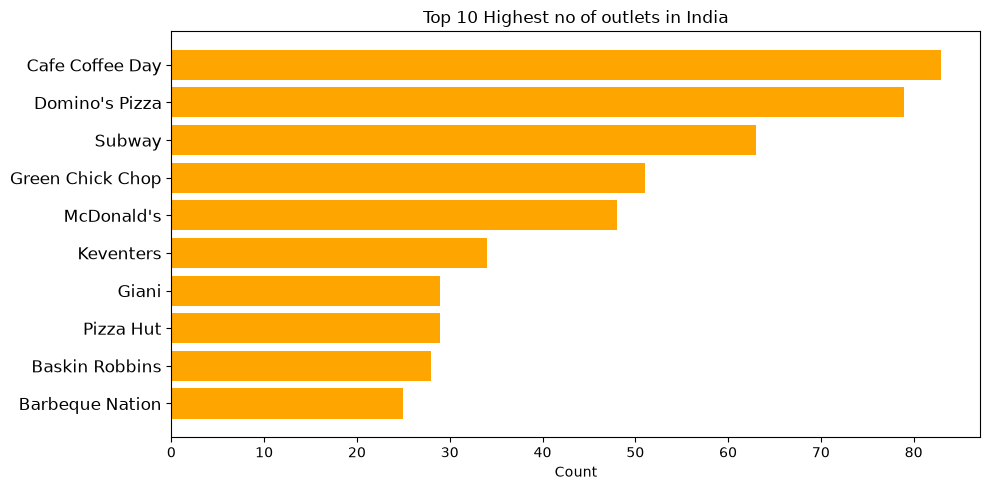

In [10]:
x = zom[zom['Country Code'] == 1].groupby('Restaurant Name').size().sort_values(ascending=False).head(10)

x = x.iloc[::-1]
plt.figure(figsize=(10,5))
plt.barh(x.index, x.values, color='orange')
plt.xlabel('Count')
plt.title('Top 10 Highest no of outlets in India')
plt.yticks(fontsize=12)
plt.tight_layout()


In [11]:
country = pd.read_excel('Country-Code.xlsx')
country.head(15)

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
zom = zom.merge(country, on='Country Code', how='left')
zom.head(3)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines


In [ ]:
print('Here, there is a list of Zomato country:')
for i in pd.unique(zom.Country): print(i)
print('Total number of countries is:', len(pd.unique(zom.Country)))

Here, there is a list of Zomato country:
Phillipines
Brazil
United States
Australia
Canada
Singapore
UAE
India
Indonesia
New Zealand
United Kingdom
Qatar
South Africa
Sri Lanka
Turkey
Total number of countries is: 15


#### Zomato is available in these 15 countries

In [ ]:
zom.Country.value_counts()

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
South Africa        60
UAE                 60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Qatar               20
Singapore           20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

## Top 3 country that heavily uses Zomato
   Let's see this by ploting

In [ ]:
country_name = zom.Country.value_counts().index
country_name 

Index(['India', 'United States', 'United Kingdom', 'Brazil', 'South Africa',
       'UAE', 'New Zealand', 'Turkey', 'Australia', 'Phillipines', 'Indonesia',
       'Qatar', 'Singapore', 'Sri Lanka', 'Canada'],
      dtype='object', name='Country')

In [ ]:
country_count = zom.Country.value_counts().values
country_count

array([8652,  434,   80,   60,   60,   60,   40,   34,   24,   22,   21,
         20,   20,   20,    4])

(np.float64(-1.0999999643820955),
 np.float64(1.099999738983165),
 np.float64(-1.099999960209158),
 np.float64(1.0999997007560611))

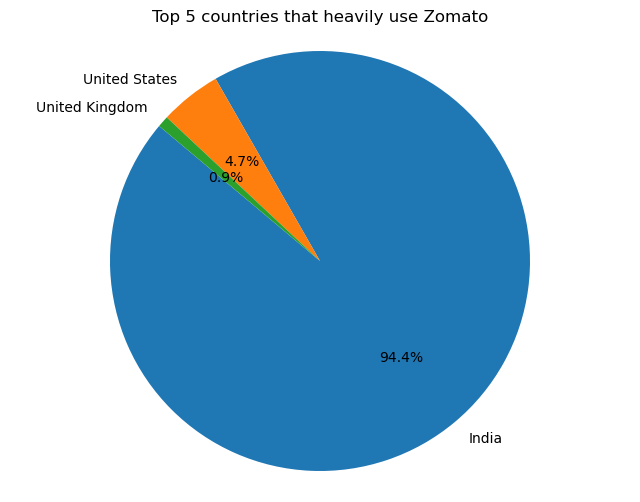

In [ ]:
plt.figure(figsize=(8,6))
plt.pie(country_count[:3], labels=country_name[:3], autopct='%1.1f%%', startangle=140)
plt.title('Top 5 countries that heavily use Zomato')
plt.axis('equal')

Observation:Zomato Maximum Records are from India After that USA and then United Kingdom